# Quantity Analysis - Time Series

## Objective
Analyze and forecast **quantity trends** over time using time series analysis techniques.

## Dataset Overview
The dataset contains timestamped records of quantities sold or produced.

## Workflow
1. Load the data
2. Explore time-based patterns
3. Resample and smooth
4. Train a forecasting model
5. Visualize predictions

In [8]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")


In [7]:
# Load data from Excel file
FILE_PATH = "Raw Data_Predictive Analysis.xlsx"  # update path if needed

df = pd.read_excel(FILE_PATH)

print("Shape:", df.shape)
df.head()

Shape: (40563, 9)


,OrderDate,ParentProductIdNew,ParentProductNew,ProductCategoryNew,ArtistNameNew,total_qty_sales,Selling Price,productListViews,productListClicks
0,2019-01-01,11,Product 11,Category 1,TSSOS,3,399.0,NaN,NaN
1,2019-01-01,114,Product 114,Category 8,TSSA,10,549.0,NaN,NaN
2,2019-01-01,98,Product 98,Category 8,TSSHT,8,499.0,NaN,NaN
3,2019-01-01,97,Product 97,Category 8,TSSF,6,549.0,NaN,NaN
4,2019-01-01,8,Product 8,Category 1,TSSML,6,399.0,NaN,NaN


## Exploratory Data Analysis

count      731.000000
mean       795.470588
std        712.046678
min         91.000000
25%        353.000000
50%        780.000000
75%       1025.500000
max      11424.000000
Name: total_qty_sales, dtype: float64


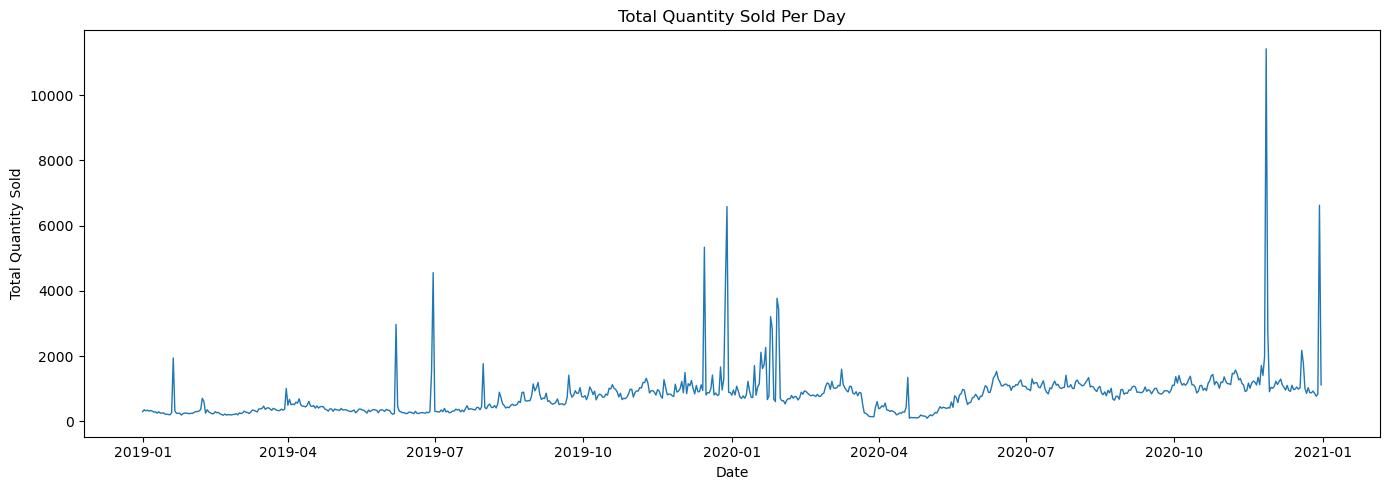

In [9]:
# Convert to datetime if necessary
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

# This dataset has one row per product, per order date (multiple products can sell on the same day).
# For a single time series, aggregate quantity sold across all products for each date.
daily_qty = df.groupby('OrderDate')['total_qty_sales'].sum().sort_index()

# Make sure every calendar day is represented (fill any missing days with 0 sales)
daily_qty = daily_qty.asfreq('D').fillna(0)
daily_qty.index.name = 'OrderDate'

print(daily_qty.describe())

# Plot raw time series
plt.figure(figsize=(14, 5))
plt.plot(daily_qty.index, daily_qty.values, linewidth=1)
plt.title('Total Quantity Sold Per Day')
plt.xlabel('Date')
plt.ylabel('Total Quantity Sold')
plt.tight_layout()
plt.show()

## Decomposition

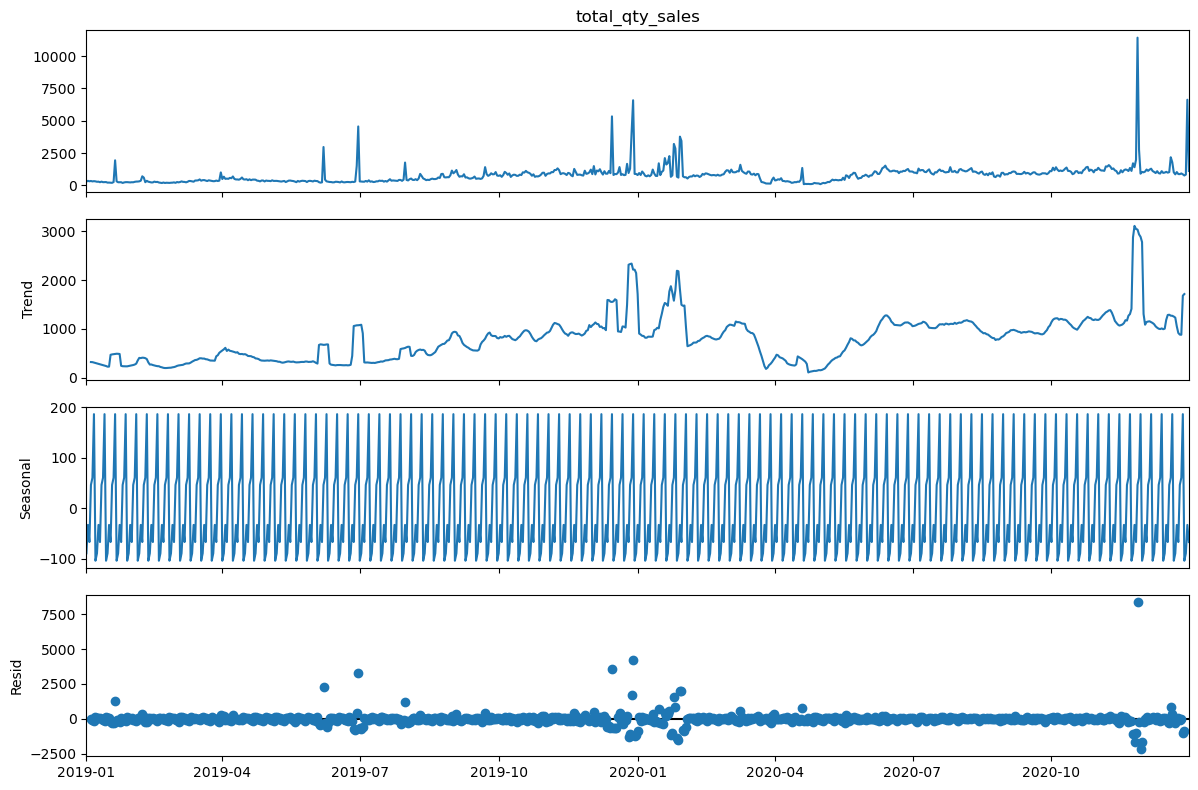

In [10]:
# Set date as index (already a DatetimeIndex from the groupby above)
ts = daily_qty.copy()

# Decompose the series into trend, weekly seasonality, and residual components
decomposition = seasonal_decompose(ts, model='additive', period=7)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

## Modeling with ARIMA

In [11]:
# Train-test split (last 10% of days held out for testing)
train_size = int(len(ts) * 0.9)
train, test = ts.iloc[:train_size], ts.iloc[train_size:]

print(f"Train size: {len(train)} days | Test size: {len(test)} days")

# Fit ARIMA model
# order=(p,d,q) -- start with a simple baseline; tune using ACF/PACF plots or auto_arima for better results
model = ARIMA(train, order=(2, 1, 2))
fitted_model = model.fit()
print(fitted_model.summary())

# Forecast over the test period
forecast_result = fitted_model.get_forecast(steps=len(test))
forecast = forecast_result.predicted_mean
forecast.index = test.index
conf_int = forecast_result.conf_int()
conf_int.index = test.index

Train size: 657 days | Test size: 74 days
                               SARIMAX Results                                
Dep. Variable:        total_qty_sales   No. Observations:                  657
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -4922.150
Date:                Sat, 26 Sep 2026   AIC                           9854.301
Time:                        18:09:48   BIC                           9876.732
Sample:                    01-01-2019   HQIC                          9862.997
                         - 10-18-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0860      0.246      0.350      0.726      -0.396       0.568
ar.L2         -0.0737      0.088     -0.837      0.403      -0.246       0.099
ma.L1     

## Evaluation and Visualization

RMSE: 1402.59
MAE:  411.47
MAPE: 16.97%


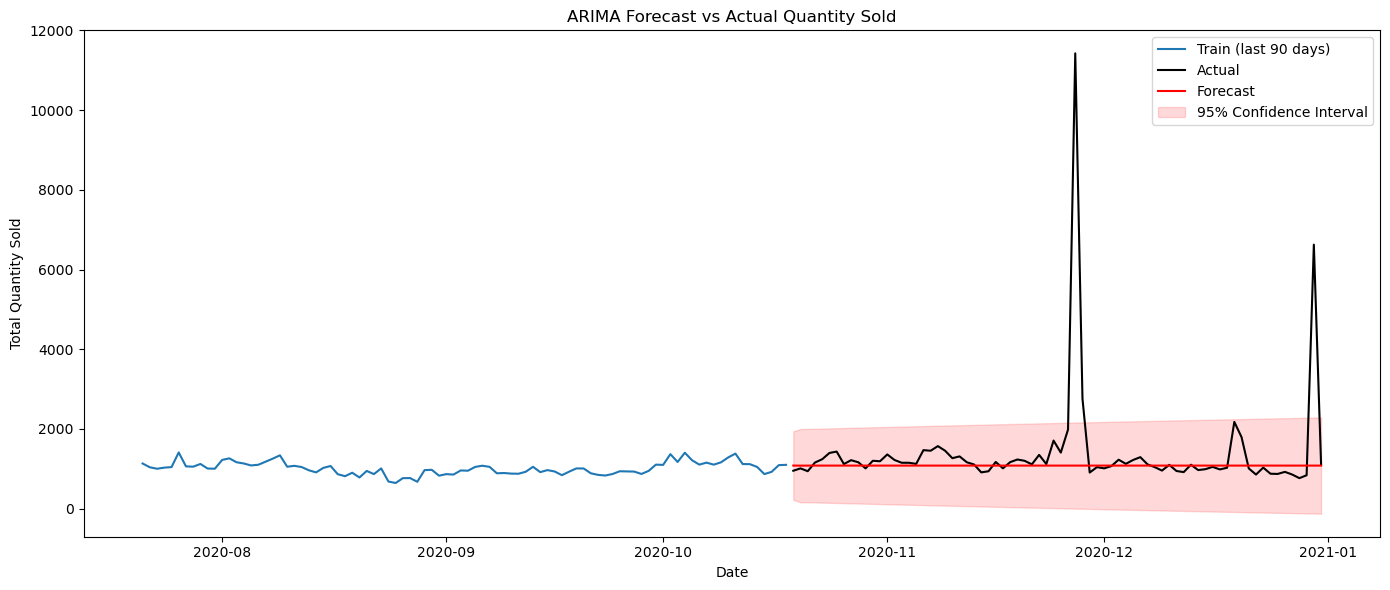

In [12]:
# Evaluation
rmse = np.sqrt(mean_squared_error(test, forecast))
mae = mean_absolute_error(test, forecast)
mape = np.mean(np.abs((test - forecast) / test.replace(0, np.nan))) * 100

print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"MAPE: {mape:.2f}%")

# Plot forecast vs actual
plt.figure(figsize=(14, 6))
plt.plot(train.index[-90:], train.values[-90:], label='Train (last 90 days)')
plt.plot(test.index, test.values, label='Actual', color='black')
plt.plot(forecast.index, forecast.values, label='Forecast', color='red')
plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1],
                  color='red', alpha=0.15, label='95% Confidence Interval')
plt.title('ARIMA Forecast vs Actual Quantity Sold')
plt.xlabel('Date')
plt.ylabel('Total Quantity Sold')
plt.legend()
plt.tight_layout()
plt.show()

## Conclusion
- Time series modeling was applied to understand and forecast quantity trends.
- ARIMA provided a simple baseline.
- For improvement, consider SARIMA, Prophet, or LSTM for long-term patterns.